In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
# Install
!pip install -q transformers datasets scikit-learn accelerate seaborn

In [ ]:
# Import
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

print("GPU:", torch.cuda.is_available())

GPU: True


In [ ]:
# Load Dataset
dataset = load_dataset("visolex/VN-HSD")
full_ds = dataset["train"]

full_ds = full_ds.filter(lambda x: x["comment"] is not None)

def ensure_string(example):
    example["comment"] = str(example["comment"])
    return example

full_ds = full_ds.map(ensure_string)

df = full_ds.to_pandas()

print("Dataset size:", len(df))
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

HSD.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/40532 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40532 [00:00<?, ? examples/s]

Map:   0%|          | 0/40531 [00:00<?, ? examples/s]

Dataset size: 40531


,dataset,type,comment,label
0,ViHSD,train,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,ViHSD,train,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,ViHSD,train,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,ViHSD,train,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,ViHSD,train,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


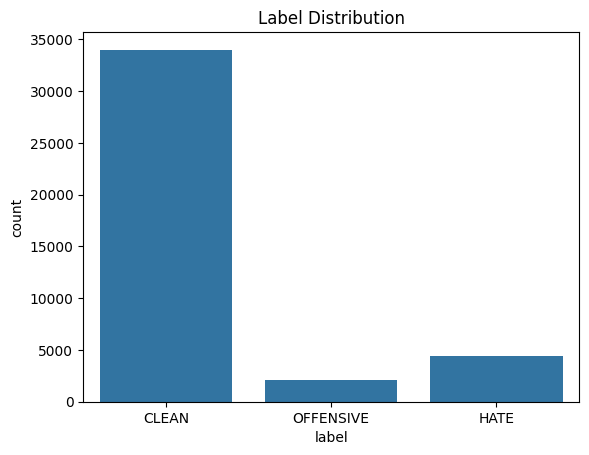

label
0    0.838790
2    0.109570
1    0.051639
Name: proportion, dtype: float64


In [ ]:
# Dataset analysis
label_names = ["CLEAN", "OFFENSIVE", "HATE"]

plt.figure()
sns.countplot(x=df["label"])
plt.title("Label Distribution")
plt.xticks([0,1,2], label_names)
plt.show()

print(df["label"].value_counts(normalize=True))

In [ ]:
# Train 80/20
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 32424
Test: 8107


# BASELINE MODEL — TF-IDF + SVM

In [ ]:
# TF-IDF
y_train = train_df["label"]
y_test  = test_df["label"]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

X_train = tfidf.fit_transform(train_df["comment"])
X_test  = tfidf.transform(test_df["comment"])

In [ ]:
# Train SVM
svm = LinearSVC()
svm.fit(X_train, y_train)

svm_preds = svm.predict(X_test)

In [ ]:
# Evaluate SVM
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, svm_preds, average="macro"
)

svm_acc = accuracy_score(y_test, svm_preds)

print("=== TF-IDF + SVM ===")
print("Accuracy:", svm_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=label_names))

svm_f1 = f1

=== TF-IDF + SVM ===
Accuracy: 0.8771432095719749
Precision: 0.690060989328682
Recall: 0.5418817515395502
F1: 0.5891846409976961

Classification Report:
              precision    recall  f1-score   support

       CLEAN       0.90      0.98      0.94      6800
   OFFENSIVE       0.50      0.23      0.31       419
        HATE       0.67      0.42      0.52       888

    accuracy                           0.88      8107
   macro avg       0.69      0.54      0.59      8107
weighted avg       0.86      0.88      0.86      8107



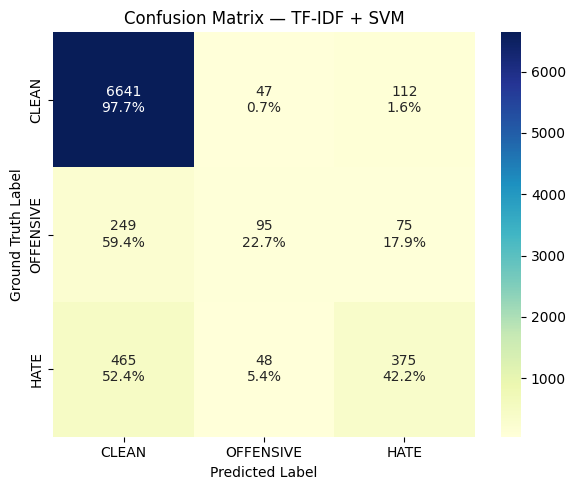

In [ ]:
cm = confusion_matrix(y_test, svm_preds)

cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

labels = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        row.append(f"{cm[i,j]}\n{cm_percent[i,j]*100:.1f}%")
    labels.append(row)

labels = np.array(labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="YlGnBu",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Ground Truth Label")
plt.title("Confusion Matrix — TF-IDF + SVM")

plt.tight_layout()
plt.show()

# PHOBERT MODEL

In [ ]:
# Convert Dataset
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

In [ ]:
# Tokenizer
MODEL_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Tokenazation
def tokenize(batch):
    return tokenizer(
        batch["comment"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tok = train_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

train_tok = train_tok.remove_columns(
    [c for c in train_tok.column_names if c not in ["input_ids","attention_mask","label"]]
)

test_tok = test_tok.remove_columns(
    [c for c in test_tok.column_names if c not in ["input_ids","attention_mask","label"]]
)

train_tok.set_format("torch")
test_tok.set_format("torch")

Map:   0%|          | 0/32424 [00:00<?, ? examples/s]

Map:   0%|          | 0/8107 [00:00<?, ? examples/s]

In [ ]:
# Model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [ ]:
# Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


training_args = TrainingArguments(
    output_dir="./phobert",

    eval_strategy="epoch",      # evaluate mỗi epoch
    logging_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    num_train_epochs=10,
    weight_decay=0.01,

    fp16=True,
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tok,
    eval_dataset=test_tok,

    compute_metrics=compute_metrics
)


trainer.train()

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.469997,0.378072,0.868509,0.640285,0.503266,0.530846
2,0.356163,0.364063,0.873319,0.731183,0.504271,0.560427
3,0.297633,0.354441,0.882571,0.727690,0.570991,0.618498
4,0.248190,0.354871,0.876897,0.674197,0.610860,0.637753
5,0.203290,0.386906,0.875170,0.672047,0.611194,0.635169
6,0.168797,0.430580,0.862711,0.635431,0.645095,0.639269
7,0.136217,0.469737,0.873689,0.664902,0.613608,0.635806
8,0.115349,0.485827,0.871099,0.651139,0.623487,0.636264
9,0.095040,0.519152,0.869249,0.647192,0.626199,0.636176
10,0.082710,0.528829,0.870729,0.652595,0.620676,0.635313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5070, training_loss=0.21733864628116525, metrics={'train_runtime': 2164.1678, 'train_samples_per_second': 149.822, 'train_steps_per_second': 2.343, 'total_flos': 2.132797364103168e+16, 'train_loss': 0.21733864628116525, 'epoch': 10.0})

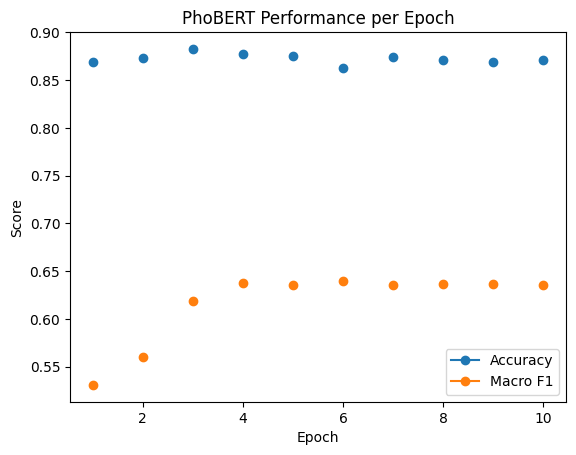

In [ ]:
history = trainer.state.log_history
df_history = pd.DataFrame(history)

metrics = df_history[df_history["epoch"].notna()]

plt.figure()

plt.plot(metrics["epoch"], metrics["eval_accuracy"], marker="o", label="Accuracy")
plt.plot(metrics["epoch"], metrics["eval_f1"], marker="o", label="Macro F1")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("PhoBERT Performance per Epoch")
plt.legend()

plt.show()

In [ ]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.123103,0.491620,0.866165,0.647303,0.607057,0.622735
2,0.096829,0.543317,0.869372,0.651607,0.603672,0.624883
3,0.076911,0.600432,0.873196,0.667811,0.611723,0.635956
4,0.060864,0.629915,0.873319,0.665184,0.616149,0.635781
5,0.044030,0.716156,0.876773,0.680407,0.601062,0.632676
6,0.040463,0.749086,0.858024,0.626692,0.651179,0.637368
7,0.029760,0.813957,0.874183,0.668736,0.618047,0.640156
8,0.020273,0.861908,0.866165,0.641242,0.638227,0.639007
9,0.017047,0.838474,0.873443,0.665334,0.622738,0.642017
10,0.011729,0.854084,0.871222,0.658729,0.618498,0.636776


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5070, training_loss=0.05210093229244917, metrics={'train_runtime': 2155.7209, 'train_samples_per_second': 150.409, 'train_steps_per_second': 2.352, 'total_flos': 2.132797364103168e+16, 'train_loss': 0.05210093229244917, 'epoch': 10.0})

In [ ]:
# Evaluate
outputs = trainer.predict(test_tok)

phobert_preds = np.argmax(outputs.predictions, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    phobert_preds,
    average="macro"
)

phobert_acc = accuracy_score(y_test, phobert_preds)

print("--- PhoBERT ---")
print("Accuracy:", phobert_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nClassification Report:")
print(classification_report(y_test, phobert_preds, target_names=label_names))

phobert_f1 = f1

--- PhoBERT ---
Accuracy: 0.8712224003947207
Precision: 0.6587294041516083
Recall: 0.6184978576779784
F1: 0.6367758585990401

Classification Report:
              precision    recall  f1-score   support

       CLEAN       0.92      0.95      0.93      6800
   OFFENSIVE       0.45      0.38      0.41       419
        HATE       0.61      0.52      0.56       888

    accuracy                           0.87      8107
   macro avg       0.66      0.62      0.64      8107
weighted avg       0.86      0.87      0.87      8107



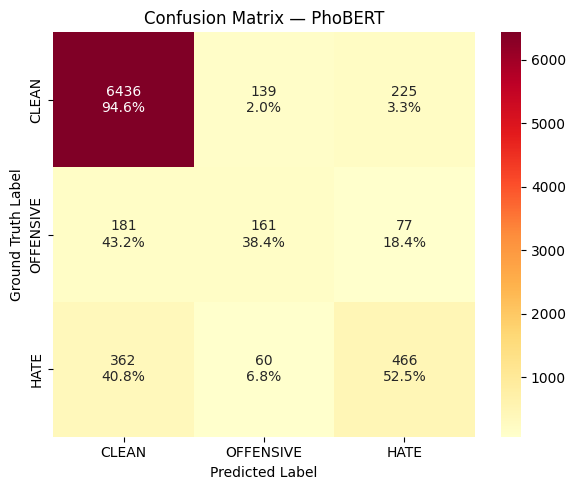

In [ ]:
cm = confusion_matrix(y_test, phobert_preds)

cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

labels = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        row.append(f"{cm[i,j]}\n{cm_percent[i,j]*100:.1f}%")
    labels.append(row)

labels = np.array(labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="YlOrRd",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Ground Truth Label")
plt.title("Confusion Matrix — PhoBERT")

plt.tight_layout()
plt.show()

# MODEL COMPARISON

In [ ]:
# MODEL COMPARISON
results = pd.DataFrame({
    "Model": ["TF-IDF + SVM", "PhoBERT"],
    "Accuracy": [svm_acc, phobert_acc],
    "Macro F1": [svm_f1, phobert_f1]
})

print(results)

          Model  Accuracy  Macro F1
0  TF-IDF + SVM  0.877143  0.589185
1       PhoBERT  0.871222  0.636776


# ERROR ANALYSIS

In [ ]:
errors = test_df.copy()
errors["prediction"] = phobert_preds

wrong = errors[errors["label"] != errors["prediction"]]
print("Number of wrong predictions:", len(wrong))

wrong.head(10)

Number of wrong predictions: 1044


,dataset,type,comment,label,prediction
40019,ViCTSD,test,"sao ko lấy lao mà đâm nó , để nó tấn công vậy ...",2,0
29484,ViHSD,test,"Tôi không chạy cũng không xin, không thoái thá...",0,2
25081,ViHSD,test,Họ nhìn con này sao họ mới gọi nói như ...,0,2
18366,ViHSD,train,Tại vì refund có 4 người cùng nhau đạt top 1 c...,0,2
33309,ViCTSD,train,"Bản tính trẻ con là ham chơi, không bao giờ có...",0,2
5555,ViHSD,train,Nhà con đó giàu mà. Bắt nó đền đi. :)),0,2
11410,ViHSD,train,"Đố mấy bạn ...có bao nhiêu chữ ""Đụ"" 😁😁",0,1
37056,ViCTSD,train,Ác quá.,2,0
22613,ViHSD,dev,Lũ chó đói,1,2
13886,ViHSD,train,Trẻ trâu Việt Nam lúc này:,2,0


# DEMO PREDICTION

In [ ]:
# Interactive demo
def predict(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    return label_names[pred]


while True:

    text = input("\nEnter Vietnamese comment (or 'quit'): ")

    if text.lower() == "quit":
        break

    print("Prediction:", predict(text))


Enter Vietnamese comment (or 'quit'): sao chúng mày ngu thế
Prediction: HATE

Enter Vietnamese comment (or 'quit'): dị tật vãi lồn
Prediction: OFFENSIVE

Enter Vietnamese comment (or 'quit'): như con cặc
Prediction: OFFENSIVE

Enter Vietnamese comment (or 'quit'): ở đây toàn người tốt
Prediction: CLEAN

Enter Vietnamese comment (or 'quit'): hay lắm bạn ơi
Prediction: CLEAN

Enter Vietnamese comment (or 'quit'): quit


In [ ]:
# SAVE PHOBERT MODEL

trainer.save_model("phobert_model")
tokenizer.save_pretrained("phobert_model")

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [ ]:
import os
os.listdir()

['.config', 'phobert_model', 'phobert', 'sample_data']

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# LOAD MODEL
model_path = "phobert_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    pred = torch.argmax(probs).item()

    return pred, probs.detach().numpy()

In [ ]:
text = "Quán ăn rất ngon và phục vụ tuyệt vời"

pred, probs = predict_sentiment(text)

print("Prediction:", pred)
print("Probabilities:", probs)

Prediction: 0
Probabilities: [[9.9984396e-01 2.0033716e-05 1.3598433e-04]]


In [ ]:
import joblib

joblib.dump(svm, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Baseline models saved successfully!")

Baseline models saved successfully!


In [ ]:
import os
os.listdir()

['.config',
 'tfidf_vectorizer.pkl',
 'phobert_model',
 'svm_model.pkl',
 'phobert',
 'sample_data']

In [ ]:
svm = joblib.load("svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Baseline model loaded successfully!")

Baseline model loaded successfully!


In [ ]:
def predict_baseline(text):

    vec = tfidf.transform([text])
    pred = svm.predict(vec)

    return pred[0]


text = "Quán ăn rất ngon và phục vụ tốt"

print("Baseline prediction:", predict_baseline(text))

Baseline prediction: 0


In [ ]:
from google.colab import files
files.download("svm_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r phobert_model.zip phobert_model

  adding: phobert_model/ (stored 0%)
  adding: phobert_model/config.json (deflated 53%)
  adding: phobert_model/bpe.codes (deflated 59%)
  adding: phobert_model/tokenizer_config.json (deflated 77%)
  adding: phobert_model/added_tokens.json (stored 0%)
  adding: phobert_model/training_args.bin (deflated 53%)
  adding: phobert_model/vocab.txt (deflated 55%)
  adding: phobert_model/model.safetensors (deflated 14%)


In [ ]:
from google.colab import files
files.download("phobert_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import joblib
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification

st.title("Vietnamese Hate Speech Detection")

label_names = ["CLEAN", "OFFENSIVE", "HATE"]

# Load models
tokenizer = AutoTokenizer.from_pretrained("phobert_model")
model = AutoModelForSequenceClassification.from_pretrained("phobert_model")

svm = joblib.load("svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

model_choice = st.selectbox(
    "Choose model",
    ["PhoBERT", "TF-IDF + SVM"]
)

text = st.text_area("Enter Vietnamese comment")

if st.button("Predict"):

    if model_choice == "PhoBERT":

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        with torch.no_grad():
            outputs = model(**inputs)

        pred = torch.argmax(outputs.logits).item()

        st.success("Prediction: " + label_names[pred])


    if model_choice == "TF-IDF + SVM":

        vec = tfidf.transform([text])
        pred = svm.predict(vec)[0]

        st.success("Prediction: " + label_names[pred])

Writing app.py


In [ ]:
!ngrok config add-authtoken 3AtUjdrjNePupaliAkA7YrBe8wT_7FEZMvdXDKU3Rj1Szkaa9

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!ls

app.py	 phobert_model	    sample_data    tfidf_vectorizer.pkl
phobert  phobert_model.zip  svm_model.pkl


In [ ]:
from pyngrok import ngrok
import threading
import os

def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit)
thread.start()

public_url = ngrok.connect(8501)

print("Demo link:")
print(public_url)


Demo link:
NgrokTunnel: "https://screaky-peeringly-eleni.ngrok-free.dev" -> "http://localhost:8501"


## Nếu muốn dùng Ngrok link để mở demo, hãy luôn nhớ chạy lại colab do sau khi tắt colab đi là link Ngrok sẽ không vào được dù code đã save